## Task 1: Preprocess and Explore the Data

### 1. Imports and Setup

This section imports all libraries needed for data extraction, cleaning,
visualization, and statistical testing:
- `yfinance` to pull historical price data
- `pandas` / `numpy` for data manipulation
- `matplotlib` / `seaborn` for visualization
- `statsmodels` for the Augmented Dickey-Fuller stationarity test

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('deep')

### 2. Extract Historical Financial Data

We fetch daily OHLCV (Open, High, Low, Close, Volume) data for **TSLA**,
**BND**, and **SPY** from January 1, 2015 to June 30, 2026 using YFinance.

Each asset's data is downloaded separately and stored in a dictionary,
then combined into a single long-format DataFrame with a `Ticker` column
to identify which rows belong to which asset. This structure makes it
easy to group, filter, and compare assets later.

`try/except` blocks are used throughout so a failed download or
processing step for one ticker doesn't crash the entire pipeline.

In [7]:
tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-06-30'

raw_data = {}

for ticker in tickers:
    try:
        df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
        if df.empty:
            raise ValueError(f"No data returned for {ticker}")
        raw_data[ticker] = df
        print(f"Downloaded {ticker}: {df.shape[0]} rows")
    except Exception as e:
        print(f"Error downloading {ticker}: {e}")

# Combine into a single long-format DataFrame with an asset identifier
combined_frames = []

for ticker, df in raw_data.items():
    try:
        temp = df.copy()
        temp['Ticker'] = ticker
        temp = temp.reset_index()
        combined_frames.append(temp)
    except Exception as e:
        print(f"Error processing {ticker} into combined frame: {e}")

try:
    combined_df = pd.concat(combined_frames, ignore_index=True)
    print(combined_df.head())
except Exception as e:
    print(f"Error concatenating dataframes: {e}")

[*********************100%***********************]  1 of 1 completed


Downloaded TSLA: 2888 rows


[*********************100%***********************]  1 of 1 completed


Downloaded BND: 2888 rows


[*********************100%***********************]  1 of 1 completed

Downloaded SPY: 2888 rows
Price        Date  Adj Close      Close       High        Low       Open  \
Ticker                  TSLA       TSLA       TSLA       TSLA       TSLA   
0      2015-01-02  14.620667  14.620667  14.883333  14.217333  14.858000   
1      2015-01-05  14.006000  14.006000  14.433333  13.810667  14.303333   
2      2015-01-06  14.085333  14.085333  14.280000  13.614000  14.004000   
3      2015-01-07  14.063333  14.063333  14.318667  13.985333  14.223333   
4      2015-01-08  14.041333  14.041333  14.253333  14.000667  14.187333   

Price       Volume Ticker Adj Close Close High Low Open Volume Adj Close  \
Ticker        TSLA              BND   BND  BND BND  BND    BND       SPY   
0       71466000.0   TSLA       NaN   NaN  NaN NaN  NaN    NaN       NaN   
1       80527500.0   TSLA       NaN   NaN  NaN NaN  NaN    NaN       NaN   
2       93928500.0   TSLA       NaN   NaN  NaN NaN  NaN    NaN       NaN   
3       44526000.0   TSLA       NaN   NaN  NaN NaN  NaN    Na

### 3. Data Cleaning and Understanding: Statistics & Data Types

Before modeling, we inspect the dataset's shape and distribution using
`.describe()` and check that each column has the correct data type.

- `Date` is converted to a proper `datetime` type (needed for time series
  operations and plotting)
- `Ticker` is converted to a `category` type for memory efficiency and
  cleaner grouping operations

In [8]:
try:
    print("Data types:\n", combined_df.dtypes)
    print("\nBasic statistics:\n", combined_df.describe())
except Exception as e:
    print(f"Error inspecting combined_df: {e}")

try:
    combined_df['Date'] = pd.to_datetime(combined_df['Date'])
    combined_df['Ticker'] = combined_df['Ticker'].astype('category')
except Exception as e:
    print(f"Error fixing dtypes: {e}")

Data types:
 Price      Ticker
Date                 datetime64[s]
Adj Close  TSLA            float64
Close      TSLA            float64
High       TSLA            float64
Low        TSLA            float64
Open       TSLA            float64
Volume     TSLA            float64
Ticker                         str
Adj Close  BND             float64
Close      BND             float64
High       BND             float64
Low        BND             float64
Open       BND             float64
Volume     BND             float64
Adj Close  SPY             float64
Close      SPY             float64
High       SPY             float64
Low        SPY             float64
Open       SPY             float64
Volume     SPY             float64
dtype: object

Basic statistics:
 Price                  Date    Adj Close        Close         High  \
Ticker                              TSLA         TSLA         TSLA   
count                  8664  2888.000000  2888.000000  2888.000000   
mean    2020-09-27 06:13:

### 4. Handling Missing Values

We check for missing values per ticker, since gaps can occur from
holidays, data provider issues, or mismatched trading calendars across
assets.

Missing values in `Close` and `Adj Close` are filled using **linear
interpolation** within each ticker group (rather than dropping rows
outright), since financial time series are continuous and interpolation
preserves trend continuity better than forward/backward fill for small
gaps. Any remaining unfillable rows are dropped.

In [ ]:
try:
    missing_summary = combined_df.groupby('Ticker').apply(lambda x: x.isnull().sum())
    print("Missing values per ticker:\n", missing_summary)
except Exception as e:
    print(f"Error checking missing values: {e}")

try:
    combined_df = combined_df.sort_values(['Ticker', 'Date'])
    combined_df['Adj Close'] = combined_df.groupby('Ticker')['Adj Close'].transform(
        lambda x: x.interpolate(method='linear')
    )
    combined_df['Close'] = combined_df.groupby('Ticker')['Close'].transform(
        lambda x: x.interpolate(method='linear')
    )
    combined_df = combined_df.dropna(subset=['Adj Close', 'Close'])
    print("Remaining missing values:\n", combined_df.isnull().sum())
except Exception as e:
    print(f"Error handling missing values: {e}")

### 5. Save Cleaned Dataset

The cleaned, combined dataset is saved to `data/processed/` as a CSV.
This gives us a reusable checkpoint so later notebooks (modeling,
forecasting, portfolio optimization) don't need to re-fetch or
re-clean the raw data.

In [9]:
try:
    combined_df.to_csv('../data/processed/combined_assets.csv', index=False)
    print("Saved processed data.")
except Exception as e:
    print(f"Error saving processed data: {e}")

Saved processed data.


### 6. Exploratory Data Analysis: Closing Price Over Time

Plotting adjusted closing price over time for all three assets lets us
visually identify long-term trends, growth phases, and major market
events (e.g., the 2020 COVID crash, 2021-2022 volatility). TSLA is
expected to show much higher growth and volatility than BND or SPY.

In [ ]:
try:
    fig, ax = plt.subplots(figsize=(14, 6))
    for ticker in tickers:
        subset = combined_df[combined_df['Ticker'] == ticker]
        ax.plot(subset['Date'], subset['Adj Close'], label=ticker)
    ax.set_title('Adjusted Closing Price Over Time (2015-2026)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Adjusted Close Price (USD)')
    ax.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting closing prices: {e}")

### 7. Daily Percentage Change (Volatility)

We calculate daily returns as the percentage change in adjusted close
price day-over-day. This transforms the price series into a returns
series, which fluctuates around zero and makes volatility easier to
compare across assets with very different price scales (e.g., TSLA vs.
BND).

In [ ]:
try:
    combined_df['Daily_Return'] = combined_df.groupby('Ticker')['Adj Close'].pct_change()

    fig, ax = plt.subplots(figsize=(14, 6))
    for ticker in tickers:
        subset = combined_df[combined_df['Ticker'] == ticker]
        ax.plot(subset['Date'], subset['Daily_Return'], label=ticker, alpha=0.7)
    ax.set_title('Daily Percentage Change (Volatility)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Daily Return')
    ax.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error calculating/plotting daily returns: {e}")

### 8. Rolling Mean and Standard Deviation

Using a 30-day rolling window, we calculate:
- **Rolling mean**: smooths out short-term noise to reveal the
  underlying trend
- **Rolling standard deviation**: measures how volatility itself
  changes over time (volatility clustering)

The shaded band around the rolling mean visualizes periods of higher
vs. lower risk for each asset.

Error computing rolling statistics: Cannot set a DataFrame with multiple columns to the single column Rolling_Mean


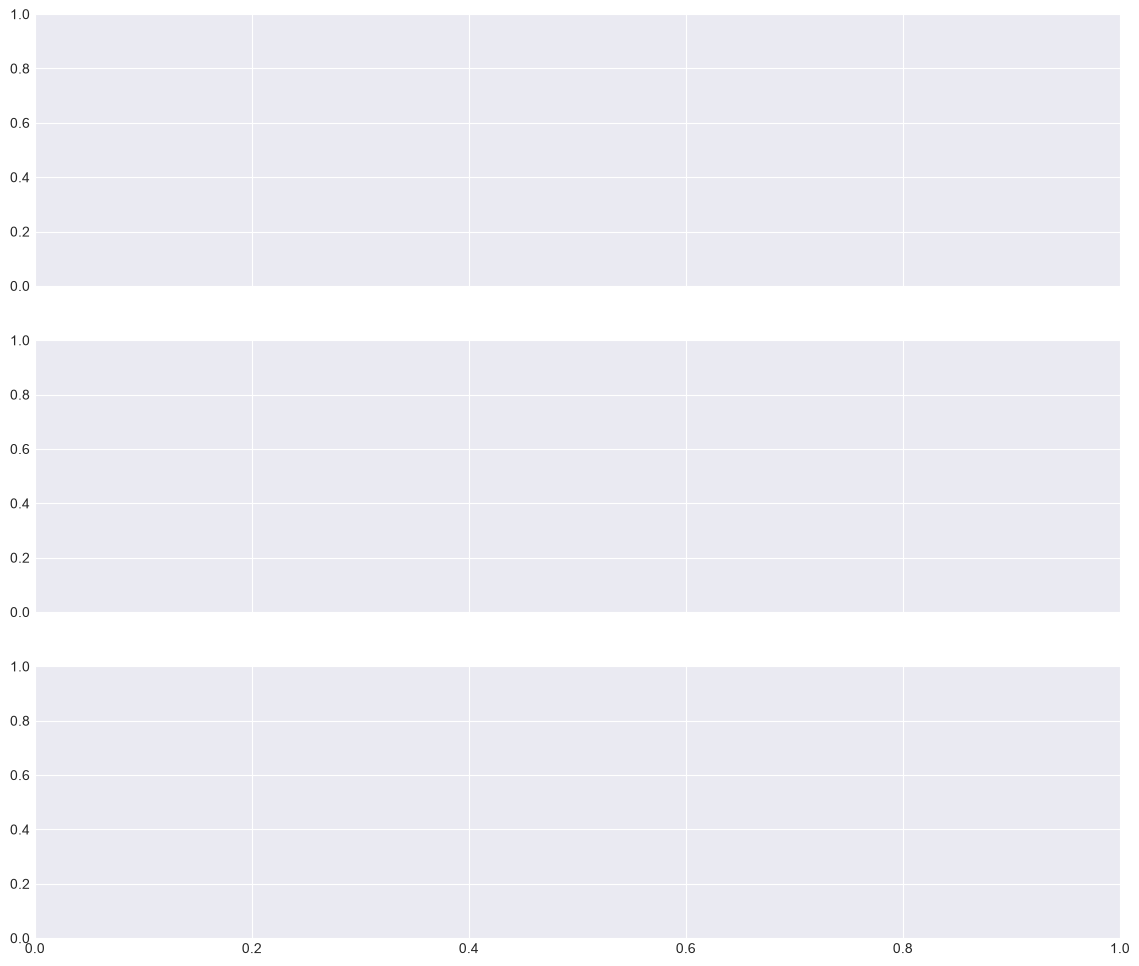

In [10]:
try:
    window = 30
    fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 12), sharex=True)

    for i, ticker in enumerate(tickers):
        subset = combined_df[combined_df['Ticker'] == ticker].copy()
        subset['Rolling_Mean'] = subset['Adj Close'].rolling(window=window).mean()
        subset['Rolling_Std'] = subset['Adj Close'].rolling(window=window).std()

        axes[i].plot(subset['Date'], subset['Adj Close'], label='Price', alpha=0.5)
        axes[i].plot(subset['Date'], subset['Rolling_Mean'], label=f'{window}-Day Rolling Mean')
        axes[i].fill_between(
            subset['Date'],
            subset['Rolling_Mean'] - subset['Rolling_Std'],
            subset['Rolling_Mean'] + subset['Rolling_Std'],
            alpha=0.2, label='Rolling Std Band'
        )
        axes[i].set_title(f'{ticker}: Rolling Mean and Std Dev ({window}-day)')
        axes[i].legend()

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error computing rolling statistics: {e}")

### 9. Outlier Detection

Days where the daily return deviates more than 3 standard deviations
from the mean are flagged as outliers. These typically correspond to
earnings announcements, macroeconomic shocks, or company-specific news
events (especially relevant for TSLA, which has a history of large
single-day moves).

In [11]:
try:
    outliers_summary = {}
    for ticker in tickers:
        subset = combined_df[combined_df['Ticker'] == ticker].copy()
        mean_ret = subset['Daily_Return'].mean()
        std_ret = subset['Daily_Return'].std()
        threshold = 3
        subset['Is_Outlier'] = np.abs(subset['Daily_Return'] - mean_ret) > (threshold * std_ret)
        outliers = subset[subset['Is_Outlier']]
        outliers_summary[ticker] = outliers[['Date', 'Daily_Return']]
        print(f"\n{ticker}: {len(outliers)} outlier days found")
        print(outliers[['Date', 'Daily_Return']].sort_values('Daily_Return').head())
except Exception as e:
    print(f"Error detecting outliers: {e}")

Error detecting outliers: 'Daily_Return'
